# Evaluation Notebook — Citation Visibility Analysis

Evaluates the effect of GEO edits on citation visibility in the LLM-generated response.
All GEO methods are compared against the baseline (`doc` = original document without any edit).

**Input:**
- `data/retail/generation/4_generation_results_v2.parquet` — LLM generation results
- `data/retail/retrieval/20260413_retrieval_results_geo_v2.csv` — Vertex AI retrieval ranks

**Preprocessing:** Only queries where all 22 methods produced exactly 10 documents are retained,
ensuring full comparability across all pairwise comparisons (500 → 402 queries).

## Structure
1. **Setup** — imports and paths
2. **Load Data** — load generation results, join retrieval ranks, apply preprocessing
3. **Descriptive Analysis** — dataset overview and distribution checks
4. **Helper Functions** — Delta Rank, PAWC, statistical utility functions
5. **H2** — effect of retrieval rank on citation visibility
6. **H3** — effect of GEO edits on citation visibility

## 1. Setup

In [37]:
# Standard library imports
import os
import math
import re
import itertools

# NLP and numerical computing
import nltk
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Statistical modeling
import statsmodels.api as sm
from scipy.stats import wilcoxon, norm, chi2
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.contingency_tables import mcnemar

# Download NLTK tokenizer data — required for PAWC sentence splitting
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Go up two levels to project root
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, "..", ".."))
data_dir     = os.path.join(project_root, "data", "retail")

print("Setup complete.")

Setup complete.


## 2. Load Data

Loads the generation results and joins the target document's retrieval rank from the
retrieval CSV. Two helper columns are added:
- `target_cited` — 1 if the target document appears in the LLM's citation list, 0 otherwise
- `target_retrieval_rank` — position of the target document in Vertex AI Search results (1–10)

**Preprocessing:** A query is retained only if every method (including baseline) returned
exactly 10 documents. This ensures all pairwise comparisons operate on identical document pools.

In [7]:
# Load generation results — one row per run (query × method combination)
results_path = os.path.join(data_dir, "generation/4_generation_results_v2.parquet")
df = pd.read_parquet(results_path)

# Ensure citation_order is a Python list — parquet may store it as numpy array
df["citation_order"] = df["citation_order"].apply(
    lambda x: x.tolist() if isinstance(x, np.ndarray) else x
)

# Load retrieval CSV and extract target document retrieval rank
# target_retrieval_rank: position of the target document in Vertex AI Search results (1–10)
retrieval_csv_path = os.path.join(data_dir, "retrieval/20260413_retrieval_results_geo_v2.csv")
df_retrieval = pd.read_csv(retrieval_csv_path)
target_retrieval = df_retrieval[df_retrieval["is_target"] == 1][["query_id", "rank"]].copy()
target_retrieval = target_retrieval.rename(columns={"rank": "target_retrieval_rank"})

# Join retrieval rank to generation results on query_id
df = df.merge(target_retrieval, on="query_id", how="left")

# Binary citation flag: 1 if target was cited in LLM response, 0 otherwise
# target_new_position is 0-based — citation_order is also 0-based
df["target_cited"] = df.apply(
    lambda row: 1 if row["target_new_position"] in row["citation_order"] else 0, axis=1
)

## --- Preprocessing ---
# Condition 1: keep only queries where every run has exactly 10 documents
docs_per_query = df.groupby("original_query_id")["num_docs"].min()
complete_docs  = set(docs_per_query[docs_per_query == 10].index)

# Condition 2: keep only queries where all 22 methods are present
expected_n_methods = df["method"].nunique()
methods_per_query  = df.groupby("original_query_id")["method"].nunique()
complete_methods   = set(methods_per_query[methods_per_query == expected_n_methods].index)

# Both conditions must be met — intersection ensures full comparability across methods
complete_queries = complete_docs & complete_methods

n_before = df["original_query_id"].nunique()
df       = df[df["original_query_id"].isin(complete_queries)].reset_index(drop=True)
n_after  = df["original_query_id"].nunique()

print(f"Queries with all 10 docs:           {len(complete_docs)}")
print(f"Queries with all {expected_n_methods} methods:       {len(complete_methods)}")
print(f"Queries passing both filters:       {len(complete_queries)}")
print(f"Preprocessing: removed {n_before - n_after} incomplete queries ({n_before} → {n_after}).")
print()

# Baseline DataFrame (method "doc" = original document without any GEO edit)
df_baseline = df[df["method"] == "doc"].reset_index(drop=True)

# All GEO methods excluding baseline
all_methods = sorted([m for m in df["method"].unique() if m != "doc"])

print(f"Total rows:               {len(df)}")
print(f"Baseline rows:            {len(df_baseline)}")
print(f"Methods to evaluate:      {len(all_methods)}")
print(f"Unique original queries:  {df['original_query_id'].nunique()}")
print(f"Rows with retrieval rank: {df['target_retrieval_rank'].notna().sum()}")

Queries with all 10 docs:           412
Queries with all 22 methods:       487
Queries passing both filters:       402
Preprocessing: removed 98 incomplete queries (500 → 402).

Total rows:               8844
Baseline rows:            402
Methods to evaluate:      21
Unique original queries:  402
Rows with retrieval rank: 8844


## 3. Descriptive Analysis

Overview of the final dataset after preprocessing. Key distributions reported:
- Documents per run — verifies the 10-document requirement is met
- Citations per LLM response — informs the max_citations parameter used in Delta Rank
- Target retrieval rank distribution — shows where target documents land in Vertex AI Search
- Overall citation rate — baseline reference for H3 comparisons
- LLM response length — contextual information on generation behavior

In [8]:
print("=" * 60)
print("DESCRIPTIVE ANALYSIS")
print("=" * 60)

# 1. Dataset overview — verify expected dimensions after preprocessing
print("\n--- 1. Dataset Overview ---")
print(f"Total runs:              {len(df)}")
print(f"Unique original queries: {df['original_query_id'].nunique()}")
print(f"Unique methods:          {df['method'].nunique()}")
print(f"Runs per query (mean):   {len(df) / df['original_query_id'].nunique():.1f}")

# 2. Documents per run — should be 10 for all runs after preprocessing
print("\n--- 2. Documents per Run ---")
print(f"Mean:   {df['num_docs'].mean():.2f} | Median: {df['num_docs'].median():.0f} | Min: {df['num_docs'].min()} | Max: {df['num_docs'].max()}")
for k, v in df['num_docs'].value_counts().sort_index().items():
    print(f"  {int(k):>2} docs: {v:>5} runs ({v/len(df):.1%})  {'█' * int(v/len(df)*100)}")

# 3. Citations per LLM response — distribution of how many docs the LLM cited per run
# median is used to set max_citations in Delta Rank
print("\n--- 3. Citations per LLM Response ---")
df["num_citations"] = df["citation_order"].apply(len)
print(f"Mean:   {df['num_citations'].mean():.2f} | Median: {df['num_citations'].median():.0f} | Min: {df['num_citations'].min()} | Max: {df['num_citations'].max()}")
for k, v in df["num_citations"].value_counts().sort_index().items():
    print(f"  {int(k):>2} citations: {v:>5} runs ({v/len(df):.1%})  {'█' * int(v/len(df)*100)}")

# 4. Target retrieval rank distribution — shows where target docs land in Vertex AI Search
# A skewed distribution toward higher ranks indicates target docs are harder to retrieve
print("\n--- 4. Target Retrieval Rank Distribution ---")
print(f"Mean: {df['target_retrieval_rank'].mean():.2f} | Median: {df['target_retrieval_rank'].median():.0f}")
for k, v in df["target_retrieval_rank"].value_counts().sort_index().items():
    print(f"  Rank {int(k):>2}: {v:>5} runs ({v/len(df):.1%})  {'█' * int(v/len(df)*50)}")

# 5. Overall citation statistics
print("\n--- 5. Overall Citation Statistics ---")
print(f"Overall citation rate: {df['target_cited'].mean():.1%}")
print(f"Cited:     {df['target_cited'].sum():.0f} / {len(df)}")
print(f"Not cited: {(1 - df['target_cited']).sum():.0f} / {len(df)}")

# 6. LLM response length
print("\n--- 6. LLM Response Length (words) ---")
df["response_length"] = df["llm_response"].apply(lambda x: len(x.split()))
print(f"Mean: {df['response_length'].mean():.1f} | Median: {df['response_length'].median():.0f} | Min: {df['response_length'].min()} | Max: {df['response_length'].max()}")

DESCRIPTIVE ANALYSIS

--- 1. Dataset Overview ---
Total runs:              8844
Unique original queries: 402
Unique methods:          22
Runs per query (mean):   22.0

--- 2. Documents per Run ---
Mean:   10.00 | Median: 10 | Min: 10 | Max: 10
  10 docs:  8844 runs (100.0%)  ████████████████████████████████████████████████████████████████████████████████████████████████████

--- 3. Citations per LLM Response ---
Mean:   6.50 | Median: 6 | Min: 0 | Max: 10
   0 citations:    99 runs (1.1%)  █
   1 citations:    32 runs (0.4%)  
   2 citations:    67 runs (0.8%)  
   3 citations:   211 runs (2.4%)  ██
   4 citations:   495 runs (5.6%)  █████
   5 citations:  1680 runs (19.0%)  ██████████████████
   6 citations:  1964 runs (22.2%)  ██████████████████████
   7 citations:  1717 runs (19.4%)  ███████████████████
   8 citations:  1236 runs (14.0%)  █████████████
   9 citations:   833 runs (9.4%)  █████████
  10 citations:   510 runs (5.8%)  █████

--- 4. Target Retrieval Rank Distribution ---

## 4. Helper Functions

### Delta Rank
Pairwise difference: `baseline_position − method_position` within the citation order.
Positive = method cited target earlier. Negative = method cited target later.
Citation positions are capped at `max_citations=6` (median citation count in our data).
Non-cited documents receive a penalty position one beyond the cap.
Adapted from Puerto (2025), who uses `max_citations=5` based on his data distribution.

### PAWC — Position-Adjusted Word Count
For each sentence citing the target document, the word count is weighted by exponential
position decay `exp(−i/(N−1))` and divided by the number of citations in that sentence.
Scores are normalized so all documents in a run sum to 1.
Adapted from Aggarwal et al. (2024).

### Statistical Tests
- **Cochran's Q** — global gatekeeper for Section 6.1 (Citation Rate)
- **McNemar** — pairwise binary test for Section 6.1
- **Wilcoxon (Pratt)** — pairwise non-parametric test for Sections 6.2 and 6.3
- **Bonferroni-Holm** — multiple testing correction across 21 simultaneous comparisons
- **Confirmatory (one-sided)** — based on prior literature expecting positive GEO effects (Aggarwal 2024)
- **Post hoc exploratory (two-sided)** — motivated by the negative effect of Statistics observed in Puerto (2025)
- **Effect sizes** — Odds Ratio for Section 6.1, r = Z/√N for Sections 6.2 and 6.3

In [36]:
# --- Delta Rank ---

def calculate_significant_improvements(df_baseline, df_method, max_citations=6):
    """
    Computes Delta Rank: baseline_position - method_position for the target document.
    Positive = method cited target earlier. Negative = method cited target later.

    Non-cited documents are penalized: position = len(citation_order after cut).
    This assigns a position one beyond the last considered citation.

    max_citations=6: set to median citation count in our data (Median=6, Mean=6.50).
    Puerto (2025) uses max_citations=5 based on his data distribution.

    Applies Wilcoxon signed-rank test with Pratt modification:
    zeros are retained in the ranking step — informative observations.
    Adapted from Puerto (2025).
    """
    all_differences = []
    n = min(len(df_baseline), len(df_method))
    df_baseline = df_baseline.reset_index(drop=True)
    df_method   = df_method.reset_index(drop=True)

    for i in range(n):
        baseline_order = df_baseline.loc[i, "citation_order"]
        method_order   = df_method.loc[i, "citation_order"]
        if isinstance(baseline_order, np.ndarray):
            baseline_order = baseline_order.tolist()[:max_citations]
        if isinstance(method_order, np.ndarray):
            method_order = method_order.tolist()[:max_citations]

        boosted_item  = df_method.loc[i, "target_new_position"]
        boosted_items = [boosted_item] if not isinstance(boosted_item, list) else boosted_item

        for item in boosted_items:
            if (item in baseline_order) and (item in method_order):
                diff = baseline_order.index(item) - method_order.index(item)
            elif (item in baseline_order) and (item not in method_order):
                diff = baseline_order.index(item) - len(method_order)
            elif (item not in baseline_order) and (item in method_order):
                diff = len(baseline_order) - method_order.index(item)
            else:
                diff = 0
            all_differences.append(diff)

    if len(all_differences) == 0:
        return {"statistic": None, "pvalue_greater": None, "pvalue_less": None,
                "pvalue_twosided": None, "Delta Rank": (None, None), "diffs": [], "r_effect": None}

    # Confirmatory: one-sided tests
    stat_g, pval_g = wilcoxon(all_differences, alternative="greater",   zero_method="pratt")
    stat_l, pval_l = wilcoxon(all_differences, alternative="less",      zero_method="pratt")
    # Post hoc: two-sided test
    stat_t, pval_t = wilcoxon(all_differences, alternative="two-sided", zero_method="pratt")

    mean_diff = np.mean(all_differences)
    std_diff  = np.std(all_differences)
    N         = len(all_differences)
    
    # Effect size r = Z / sqrt(N) — standard for Wilcoxon signed-rank test
    z_stat    = norm.ppf(1 - pval_g) if 0 < pval_g < 1 else 0.0
    r_effect  = abs(z_stat) / np.sqrt(N)

    return {
        "statistic":       stat_g,
        "pvalue_greater":  pval_g,
        "pvalue_less":     pval_l,
        "pvalue_twosided": pval_t,
        "Delta Rank":      (mean_diff, std_diff),
        "diffs":           all_differences,
        "r_effect":        r_effect,
    }


# --- PAWC ---

def get_num_words(tokens):
    """Count words longer than 2 characters — exactly like Aggarwal (2024)."""
    return len([x for x in tokens if len(x) > 2])


def extract_citations(text):
    """
    Splits LLM response into sentences and extracts citation indices per sentence.
    Returns nested list: paragraphs → sentences → (tokens, text, citations).
    Adapted from Aggarwal et al. (2024).
    """
    citation_pattern = r'\[[^\w\s]*\d+[^\w\s]*\]'
    def get_citations(sentence):
        return [int(re.findall(r'\d+', c)[0]) for c in re.findall(citation_pattern, sentence)]
    paras     = re.split(r'\n\n', text)
    sentences = [nltk.sent_tokenize(p) for p in paras if p.strip()]
    return [[(nltk.word_tokenize(s), s, get_citations(s)) for s in para] for para in sentences]


def pawc(sentences_nested, target_citation_idx, normalize=True):
    """
    Position-Adjusted Word Count for a specific target document.

    For each sentence citing the target:
        score += word_count × exp(-i/(N-1)) / num_citations_in_sentence

    Position weight decays exponentially — early sentences get higher weight.
    Normalized so all document scores in a run sum to 1.
    target_citation_idx is 1-based.
    Adapted from Aggarwal et al. (2024).
    """
    sentences = list(itertools.chain(*sentences_nested))
    n = max([max(s[2]) for s in sentences if s[2]] + [1])
    scores = [0.0 for _ in range(n)]
    for i, sent in enumerate(sentences):
        for cit in sent[2]:
            score  = get_num_words(sent[0])
            score *= math.exp(-1 * i / (len(sentences) - 1)) if len(sentences) > 1 else 1
            score /= len(sent[2])
            try:
                scores[cit - 1] += score
            except:
                pass
    total = sum(scores)
    if normalize and total > 0:
        scores = [x / total for x in scores]
    try:
        return scores[target_citation_idx - 1]
    except:
        return 0.0


def compute_pawc_for_row(row):
    """
    Computes PAWC for one run.
    target_new_position is 0-based → +1 to convert to 1-based for PAWC.
    Returns 0.0 if target not cited or on error.
    """
    try:
        sentences = extract_citations(row["llm_response"])
        return pawc(sentences, row["target_new_position"] + 1, normalize=True)
    except:
        return 0.0


print("Helper functions defined.")

Helper functions defined.


## 5. H2: Does Retrieval Rank Influence Citation Visibility?

**H2:** A higher retrieval position (closer to rank 1) significantly increases a document's citation visibility in the LLM-generated response.

### 5.1 Logistic Regression: Retrieval Rank → Citation Probability

One logistic regression model per method, with `target_retrieval_rank` as the sole 
predictor and `target_cited` (0/1) as the dependent variable. A significant negative 
coefficient confirms that a worse retrieval position reduces citation probability.

Each model tests an independent per-method question and is not compared against a 
shared null hypothesis — no multiple testing correction is therefore applied.

In [34]:
# One logistic regression model per method — DV: target_cited, IV: target_retrieval_rank
# Negative coefficient = worse retrieval rank → lower citation probability
results_logistic = []
for method in all_methods + ["doc"]:
    df_m = df[df["method"] == method].dropna(subset=["target_retrieval_rank"])
    X    = sm.add_constant(df_m["target_retrieval_rank"].values)
    y    = df_m["target_cited"].values
    try:
        result      = sm.Logit(y, X).fit(disp=0)
        coef        = result.params[1]
        pvalue      = result.pvalues[1]
        conf        = result.conf_int()[1]
        mcfadden_r2 = result.prsquared
        results_logistic.append({
            "method":      method,
            "coef":        coef,
            "pvalue":      pvalue,
            "ci_low":      conf[0],
            "ci_high":     conf[1],
            "mcfadden_r2": mcfadden_r2,
            "significant": "*" if pvalue < 0.05 else ""
        })
    except:
        pass

# Sort by coefficient — strongest retrieval dependence appears first
df_logistic = pd.DataFrame(results_logistic).sort_values("coef")

print("Logistic Regression: Effect of Retrieval Rank on Citation Probability")
print("Negative coef = worse retrieval rank → lower citation probability")
print()
print(f"{'Method':<30} {'Coef':>8} {'p-value':>12} {'95% CI':>22} {'Sig':>4} {'McF.R²':>8}")
print("-" * 90)
for _, row in df_logistic.iterrows():
    ci = f"[{row['ci_low']:.3f}, {row['ci_high']:.3f}]"
    print(f"  {row['method']:<28} {row['coef']:>8.4f} {row['pvalue']:>12.4g} {ci:>22} {row['significant']:>4} {row['mcfadden_r2']:>8.4f}")

Logistic Regression: Effect of Retrieval Rank on Citation Probability
Negative coef = worse retrieval rank → lower citation probability

Method                             Coef      p-value                 95% CI  Sig   McF.R²
------------------------------------------------------------------------------------------
  Authoritative(doc)            -0.3633    1.799e-14       [-0.456, -0.270]    *   0.1479
  UniqueWords(doc)              -0.3306    8.504e-14       [-0.417, -0.244]    *   0.1301
  doc                           -0.3109    8.632e-13       [-0.396, -0.226]    *   0.1179
  QS(doc)                       -0.3012    7.072e-12       [-0.387, -0.215]    *   0.1107
  CQS(doc)                      -0.2903    5.394e-11       [-0.377, -0.204]    *   0.0997
  TechnicalTerms(doc)           -0.2895    2.789e-11       [-0.375, -0.204]    *   0.1020
  Citations(doc)                -0.2877    1.917e-11       [-0.372, -0.204]    *   0.1018
  SimpleLanguage(doc)           -0.2797    1.512e-11

### 5.2 Ordinal Logistic Regression: Retrieval Rank → Citation Rank

Extends the binary analysis to the full ordinal outcome: the position at which the 
target document is cited in the LLM response (ranks 1–10, with 11 as a penalty for 
non-cited documents).

A positive coefficient indicates that a worse retrieval rank leads to a later citation 
position. Methods with coefficients closer to zero show greater resilience to poor 
retrieval rank.

As with the logistic regression above, each model tests an independent per-method 
question — no multiple testing correction is applied.

In [35]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

def get_citation_rank(row):
    """
    Returns the 1-based citation position of the target document.
    Non-cited documents receive a penalty rank of 11 — one position
    beyond the maximum possible citation rank (10 documents per run).
    """
    citation_order = row["citation_order"]
    target         = row["target_new_position"]
    if target in citation_order:
        return citation_order.index(target) + 1  # convert 0-based index to 1-based rank
    else:
        return 11  # penalty for non-cited documents

df["citation_rank"] = df.apply(get_citation_rank, axis=1)

# Descriptive distribution of citation ranks across all runs
print("Citation Rank Distribution:")
for k, v in df["citation_rank"].value_counts().sort_index().items():
    bar = "█" * int(v / len(df) * 50)
    print(f"  Rank {int(k):>2}: {v:>5} runs ({v/len(df):.1%})  {bar}")
print()

# One ordinal logistic regression model per method
# DV: citation_rank (1–11, ordinal) — IV: target_retrieval_rank (1–10, continuous)
# Positive coefficient = worse retrieval rank → later citation position
results_ordinal = []
for method in all_methods + ["doc"]:
    df_m = df[df["method"] == method].dropna(subset=["target_retrieval_rank"]).copy()
    df_m["citation_rank"] = df_m["citation_rank"].astype(int)

    try:
        model  = OrderedModel(
            df_m["citation_rank"],
            df_m[["target_retrieval_rank"]],
            distr="logit"    # proportional odds model
        )
        result = model.fit(method="bfgs", disp=False)
        coef   = result.params["target_retrieval_rank"]
        pvalue = result.pvalues["target_retrieval_rank"]
        results_ordinal.append({
            "method":      method,
            "coef":        coef,
            "pvalue":      pvalue,
            "significant": "*" if pvalue < 0.05 else ""
        })
    except Exception as e:
        print(f"  WARNING: {method} failed — {e}")

# Sort by coefficient — methods most sensitive to retrieval rank appear first
df_ordinal = pd.DataFrame(results_ordinal).sort_values("coef", ascending=False)

print("Ordinal Logistic Regression: Effect of Retrieval Rank on Citation Position")
print("Positive coef = worse retrieval rank → later citation position")
print()
print(f"{'Method':<30} {'Coef':>10} {'p-value':>12} {'Sig':>5}")
print("-" * 62)
for _, row in df_ordinal.iterrows():
    print(f"  {row['method']:<28} {row['coef']:>10.4f} {row['pvalue']:>12.4g} {row['significant']:>5}")

Citation Rank Distribution:
  Rank  1:   663 runs (7.5%)  ███
  Rank  2:   850 runs (9.6%)  ████
  Rank  3:   815 runs (9.2%)  ████
  Rank  4:   881 runs (10.0%)  ████
  Rank  5:   823 runs (9.3%)  ████
  Rank  6:   665 runs (7.5%)  ███
  Rank  7:   466 runs (5.3%)  ██
  Rank  8:   258 runs (2.9%)  █
  Rank  9:   131 runs (1.5%)  
  Rank 10:    42 runs (0.5%)  
  Rank 11:  3250 runs (36.7%)  ██████████████████

Ordinal Logistic Regression: Effect of Retrieval Rank on Citation Position
Positive coef = worse retrieval rank → later citation position

Method                               Coef      p-value   Sig
--------------------------------------------------------------
  Authoritative(doc)               0.5360    1.277e-38     *
  doc                              0.5348     3.95e-38     *
  SimpleLanguage(doc)              0.5263    3.706e-38     *
  QS(doc)                          0.5047     8.13e-37     *
  UniqueWords(doc)                 0.4960    9.228e-36     *
  TechnicalTerms(

## 6. H3: Do GEO Edits Enhance Citation Visibility?

**H3:** Content-based GEO edits significantly enhance a document's citation visibility within the LLM-generated response.

### 6.1 Citation Rate

Tests whether GEO edits significantly increase the probability of the target document 
being cited in the LLM response. Citation rate is defined as the proportion of queries 
in which the target document appears in the LLM's citation list.

**Cochran's Q** serves as a global gatekeeper before pairwise testing. It tests 
whether citation rates differ significantly across all 22 methods simultaneously. 
Pairwise McNemar tests are only interpreted if Q is significant. Cochran's Q is the 
natural extension of McNemar to more than two related groups and follows a Chi-squared 
distribution with k−1 degrees of freedom.

**McNemar's Test** is applied pairwise — baseline vs. each GEO method — on the 
discordant pairs: queries where the baseline was cited but the method was not (c), and 
queries where the method was cited but the baseline was not (b). Only discordant pairs 
carry information about the direction of the effect. The test is applied one-sided 
(confirmatory) and two-sided (post hoc exploratory).

**Effect size** is reported as the Odds Ratio (OR = b/c) — the ratio of improvements 
to deteriorations across discordant pairs. OR > 1 indicates more improvements than 
deteriorations.

In [55]:
# --- Step 0: Cochran's Q Test (Global Gatekeeper) ---
# Tests whether citation rates differ significantly across all 22 methods simultaneously.
# Pairwise McNemar tests are only justified if this global test is significant.
# Cochran's Q is the extension of McNemar to more than two groups.

# Build binary matrix: rows = queries, columns = methods, values = target_cited (0/1)
all_methods_incl_baseline = ["doc"] + all_methods
cited_matrix = pd.pivot_table(
    df, values="target_cited",
    index="original_query_id", columns="method", aggfunc="first"
)[all_methods_incl_baseline].dropna()

# Compute Cochran's Q statistic
# Formula: Q = (k-1) × (k × Σ(col_sums²) - total²) / (k × total - Σ(row_sums²))
n_subjects = cited_matrix.shape[0]
k          = cited_matrix.shape[1]
row_sums   = cited_matrix.sum(axis=1)
col_sums   = cited_matrix.sum(axis=0)
total      = cited_matrix.values.sum()

# Q follows a Chi-squared distribution with k-1 degrees of freedom
Q_num  = (k - 1) * (k * np.sum(col_sums ** 2) - total ** 2)
Q_den  = k * total - np.sum(row_sums ** 2)
Q_stat = Q_num / Q_den if Q_den != 0 else 0
Q_pval = 1 - chi2.cdf(Q_stat, df=k - 1)

# Format p-value — use scientific notation for very small values to avoid displaying 0
Q_pval_str = "< 2.2e-16" if Q_pval == 0.0 else (f"{Q_pval:.2e}" if Q_pval < 0.001 else f"{Q_pval:.4g}")

print("=" * 60)
print("Cochran's Q Test (Global Gatekeeper)")
print("=" * 60)
print(f"Subjects (queries): {n_subjects}  |  Methods: {k}")
print(f"Q statistic: {Q_stat:.4f}  |  df: {k-1}  |  p-value: {Q_pval_str}")
print()
if Q_pval < 0.05:
    print("→ Significant (p < 0.05): Citation rates differ across methods.")
    print("→ Proceeding with pairwise McNemar tests.")
else:
    print("→ Not significant (p >= 0.05): No global difference detected.")
    print("→ Pairwise McNemar results should be interpreted with caution.")

Cochran's Q Test (Global Gatekeeper)
Subjects (queries): 402  |  Methods: 22
Q statistic: 132.8086  |  df: 21  |  p-value: < 2.2e-16

→ Significant (p < 0.05): Citation rates differ across methods.
→ Proceeding with pairwise McNemar tests.


In [27]:
# --- Confirmatory: McNemar one-sided (greater) ---

# Extract baseline citation flags per query
df_base_cited = df[df["method"] == "doc"][["original_query_id", "target_cited"]].rename(
    columns={"target_cited": "cited_baseline"}
)

# Compute citation rate per method
citation_rate = df.groupby("method")["target_cited"].mean().reset_index()
citation_rate.columns = ["method", "citation_rate"]
baseline_citation_rate = citation_rate[citation_rate["method"] == "doc"]["citation_rate"].values[0]

mcnemar_results = []
for method in all_methods:
    df_mc = df[df["method"] == method][["original_query_id", "target_cited"]].rename(
        columns={"target_cited": "cited_method"}
    )
    merged    = df_base_cited.merge(df_mc, on="original_query_id")
    
    # Contingency table counts
    both      = ((merged["cited_baseline"] == 1) & (merged["cited_method"] == 1)).sum()
    only_base = ((merged["cited_baseline"] == 1) & (merged["cited_method"] == 0)).sum()
    only_meth = ((merged["cited_baseline"] == 0) & (merged["cited_method"] == 1)).sum()
    neither   = ((merged["cited_baseline"] == 0) & (merged["cited_method"] == 0)).sum()

    # McNemar two-sided p-value — convert to one-sided based on direction
    table  = [[both, only_base], [only_meth, neither]]
    p_two  = mcnemar(table, exact=False, correction=True).pvalue
    p_greater = p_two / 2 if only_meth > only_base else 1 - p_two / 2
    
    # Odds Ratio: b/c — ratio of improvements to deteriorations
    odds_ratio = only_meth / only_base if only_base > 0 else np.nan

    method_rate = citation_rate[citation_rate["method"] == method]["citation_rate"].values[0]
    mcnemar_results.append({
        "method":            method,
        "citation_rate":     method_rate,
        "delta":             method_rate - baseline_citation_rate,
        "b":                 only_meth,
        "c":                 only_base,
        "pvalue_greater":    p_greater,
        "pvalue_twosided":   p_two,
        "odds_ratio":        odds_ratio,
    })

df_citation = pd.DataFrame(mcnemar_results).sort_values("delta", ascending=False)

# Step 1 — raw p-values
print(f"Baseline citation rate (doc): {baseline_citation_rate:.1%}")
print()
print("Confirmatory — Step 1: McNemar One-Sided (greater), raw p-values")
print(f"{'Method':<30} {'Cit. Rate':>10} {'Delta':>8} {'p+ (raw)':>12} {'Sig':>5} {'OR':>8}")
print("-" * 80)
for _, row in df_citation.iterrows():
    sig    = "*" if row["pvalue_greater"] < 0.05 else ""
    or_str = f"{row['odds_ratio']:.3f}" if not np.isnan(row["odds_ratio"]) else "N/A"
    print(f"  {row['method']:<28} {row['citation_rate']:>9.1%} {row['delta']:>+7.1%} {row['pvalue_greater']:>12.4g} {sig:>5} {or_str:>8}")

# Step 2 — Bonferroni-Holm correction
# Controls family-wise error rate across 21 simultaneous comparisons
_, pvals_g_holm, _, _ = multipletests(df_citation["pvalue_greater"].values, method="holm")
df_citation["pvalue_greater_holm"] = pvals_g_holm

print()
print("Confirmatory — Step 2: Bonferroni-Holm Correction")
print(f"{'Method':<30} {'Cit. Rate':>10} {'Delta':>8} {'p+ (Holm)':>12} {'Sig':>5} {'OR':>8}")
print("-" * 80)
for _, row in df_citation.iterrows():
    sig    = "*" if row["pvalue_greater_holm"] < 0.05 else ""
    or_str = f"{row['odds_ratio']:.3f}" if not np.isnan(row["odds_ratio"]) else "N/A"
    print(f"  {row['method']:<28} {row['citation_rate']:>9.1%} {row['delta']:>+7.1%} {row['pvalue_greater_holm']:>12.4g} {sig:>5} {or_str:>8}")

Baseline citation rate (doc): 66.2%

Confirmatory — Step 1: McNemar One-Sided (greater), raw p-values
Method                          Cit. Rate    Delta     p+ (raw)   Sig       OR
--------------------------------------------------------------------------------
  Authoritative(doc)               67.2%   +1.0%       0.3797          1.087
  CS(doc)                          67.2%   +1.0%       0.3854          1.078
  QS(doc)                          67.2%   +1.0%       0.3809          1.085
  CQS(doc)                         66.7%   +0.5%       0.4609          1.039
  TechnicalTerms(doc)              66.7%   +0.5%       0.4602          1.041
  ContentImprovement(doc)          66.2%   +0.0%       0.5387          1.000
  Citations(doc)                   65.7%   -0.5%       0.5394          0.962
  SimpleLanguage(doc)              65.7%   -0.5%        0.542          0.957
  CQ(doc)                          64.9%   -1.2%       0.6577          0.902
  UniqueWords(doc)                 64.9%   -1

In [28]:
# --- Post Hoc Exploratory: McNemar two-sided ---
# H0: No intervention changes citation probability in either direction.
# HA: At least one intervention significantly changes citation probability.

_, pvals_t_holm, _, _ = multipletests(df_citation["pvalue_twosided"].values, method="holm")
df_citation["pvalue_twosided_holm"] = pvals_t_holm

print("Post Hoc Exploratory — Step 1: McNemar Two-Sided, raw p-values")
print(f"{'Method':<30} {'Cit. Rate':>10} {'Delta':>8} {'p (raw)':>12} {'Sig':>5} {'OR':>8}")
print("-" * 80)
for _, row in df_citation.iterrows():
    sig    = "*" if row["pvalue_twosided"] < 0.05 else ""
    or_str = f"{row['odds_ratio']:.3f}" if not np.isnan(row["odds_ratio"]) else "N/A"
    print(f"  {row['method']:<28} {row['citation_rate']:>9.1%} {row['delta']:>+7.1%} {row['pvalue_twosided']:>12.4g} {sig:>5} {or_str:>8}")

print()
print("Post Hoc Exploratory — Step 2: Bonferroni-Holm Correction")
print(f"{'Method':<30} {'Cit. Rate':>10} {'Delta':>8} {'p (Holm)':>12} {'Sig':>5} {'OR':>8}")
print("-" * 80)
for _, row in df_citation.iterrows():
    sig    = "*" if row["pvalue_twosided_holm"] < 0.05 else ""
    or_str = f"{row['odds_ratio']:.3f}" if not np.isnan(row["odds_ratio"]) else "N/A"
    print(f"  {row['method']:<28} {row['citation_rate']:>9.1%} {row['delta']:>+7.1%} {row['pvalue_twosided_holm']:>12.4g} {sig:>5} {or_str:>8}")

print()
print("OR = Odds Ratio (b/c). OR > 1 = more improvements than deteriorations.")

Post Hoc Exploratory — Step 1: McNemar Two-Sided, raw p-values
Method                          Cit. Rate    Delta      p (raw)   Sig       OR
--------------------------------------------------------------------------------
  Authoritative(doc)               67.2%   +1.0%       0.7595          1.087
  CS(doc)                          67.2%   +1.0%       0.7708          1.078
  QS(doc)                          67.2%   +1.0%       0.7619          1.085
  CQS(doc)                         66.7%   +0.5%       0.9219          1.039
  TechnicalTerms(doc)              66.7%   +0.5%       0.9203          1.041
  ContentImprovement(doc)          66.2%   +0.0%       0.9226          1.000
  Citations(doc)                   65.7%   -0.5%       0.9211          0.962
  SimpleLanguage(doc)              65.7%   -0.5%       0.9161          0.957
  CQ(doc)                          64.9%   -1.2%       0.6846          0.902
  UniqueWords(doc)                 64.9%   -1.2%       0.6935          0.907
  Fluen

### 6.2 Delta Rank

Tests whether GEO edits cause the target document to be cited earlier in the LLM 
response compared to the baseline. Delta Rank is defined as baseline_position − 
method_position within the citation order. A positive value indicates the method 
improved the citation position of the target document; a negative value indicates 
deterioration.

Citation positions are capped at max_citations=6, set to the median citation count 
observed in our data (Median=6, Mean=6.50). Non-cited documents receive a penalty 
position equal to the length of the (truncated) citation list — one position beyond 
the last cited document.

**Wilcoxon Signed-Rank Test** with **Pratt modification** is applied to the 
pairwise differences. The Pratt modification retains zero differences in the ranking 
step, treating them as informative no-change observations rather than discarding them 
as the standard Wilcoxon method would. This is appropriate given that approximately 
50% of pairwise differences are zero across all methods — discarding them would 
systematically bias the test statistic.

Baseline and method DataFrames are explicitly sorted by original_query_id before 
computing differences to ensure correct row-wise pairing.

**Effect size** is reported as r = Z / √N, where Z is derived from the one-sided 
p-value. Benchmarks: 0.1 = small, 0.3 = medium, 0.5 = large (Cohen 1992).

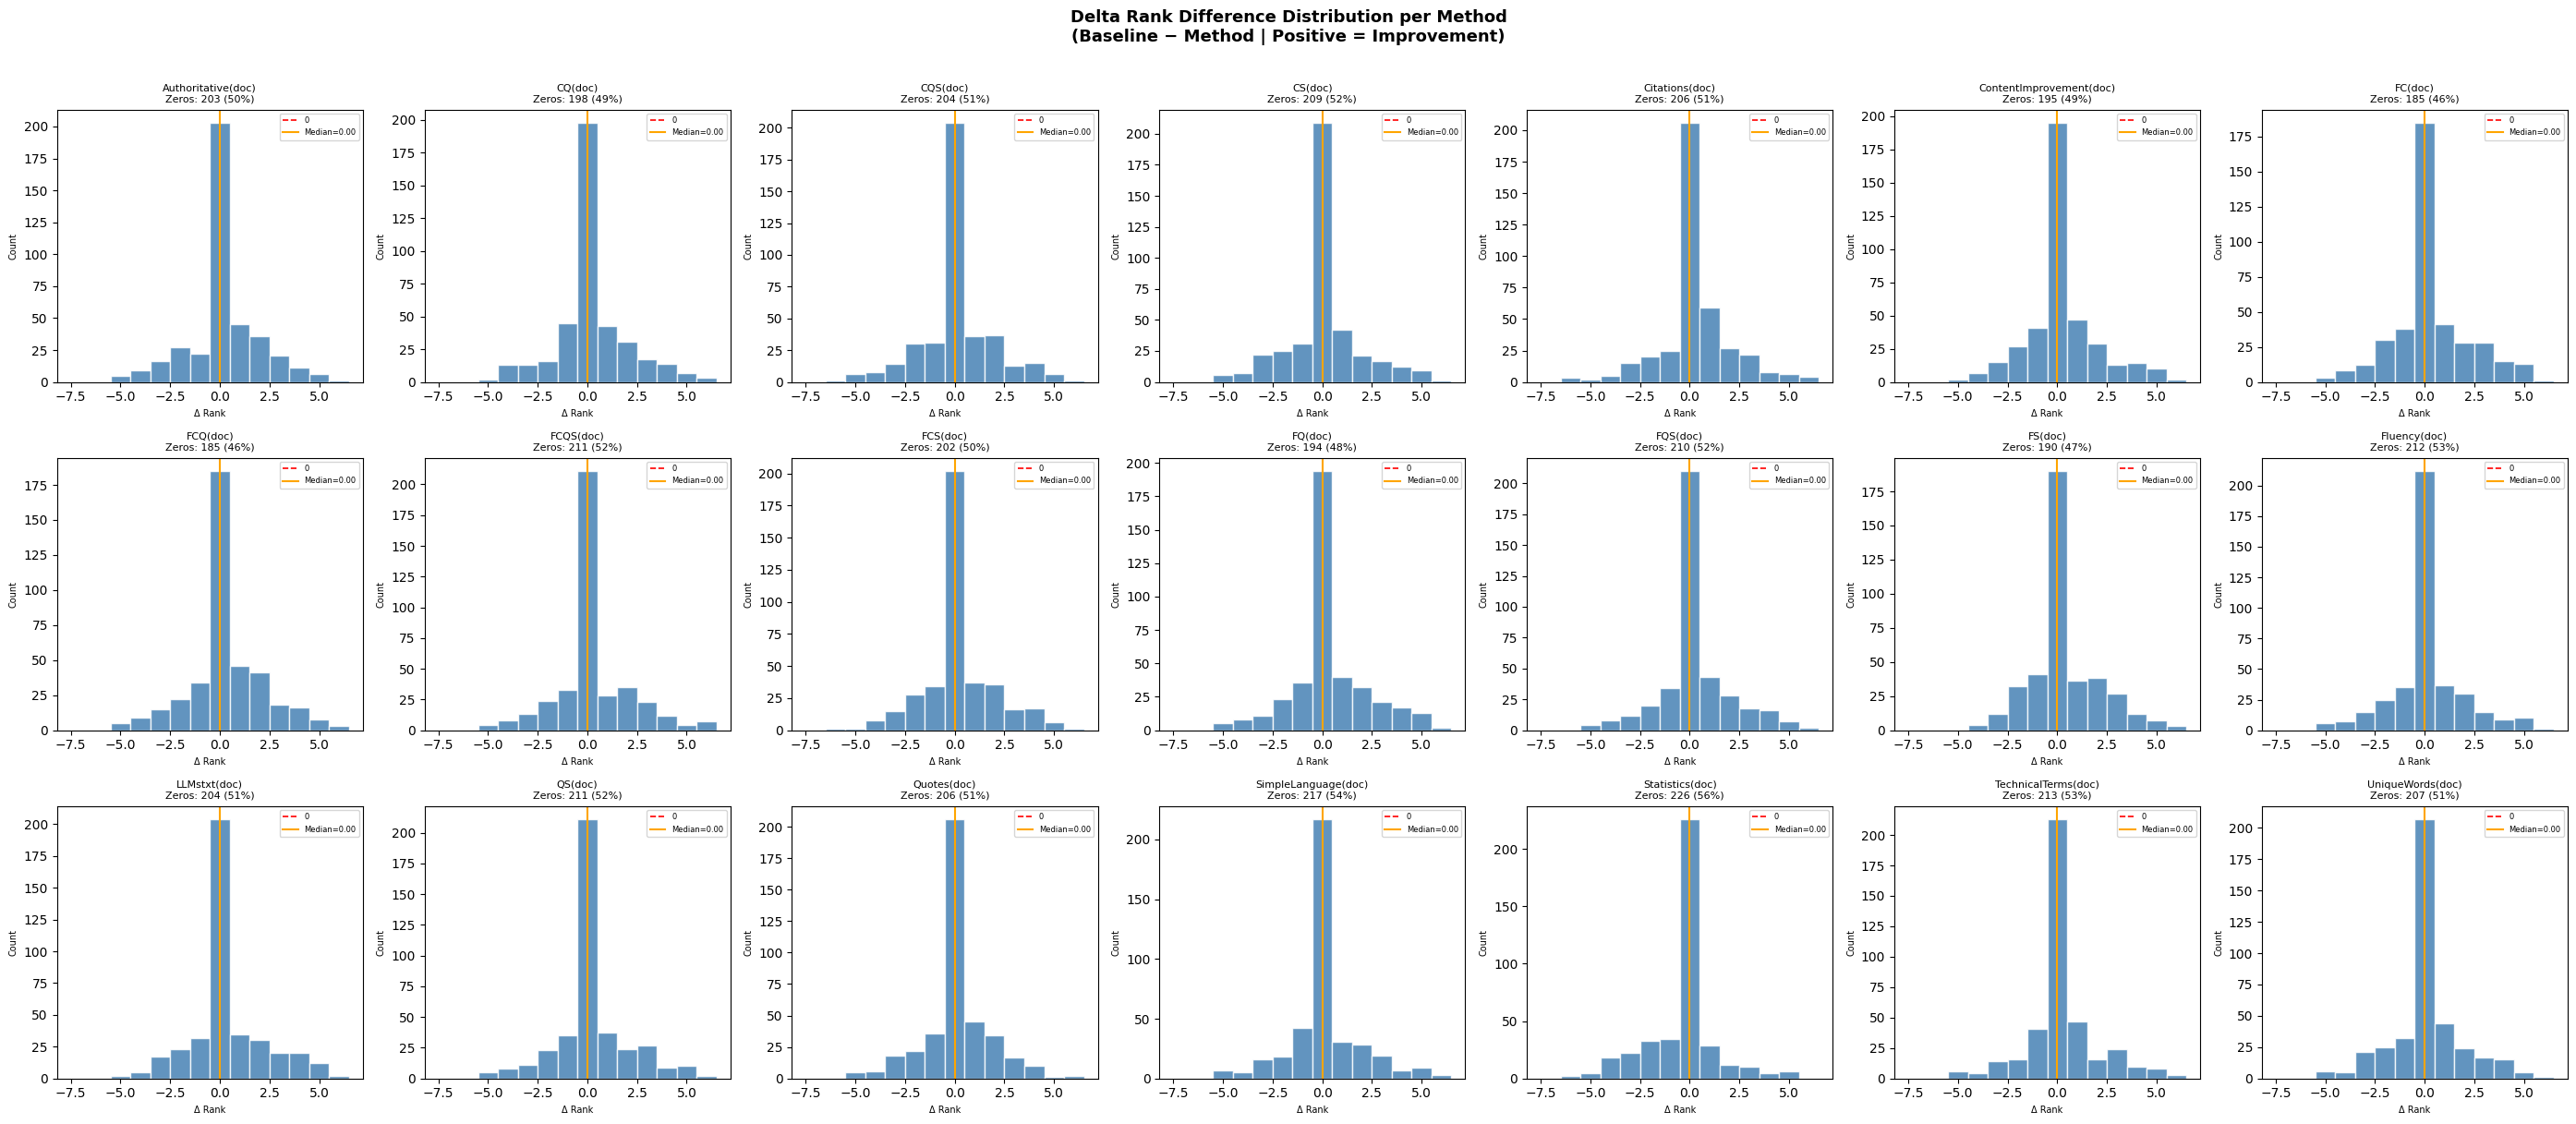


Delta Rank Symmetry Diagnostics:
Method                             N   Zeros   %Zeros   Median     Mean     Skew
--------------------------------------------------------------------------------
  Authoritative(doc)             402     203    50.5%    0.000    0.187   -0.006
  CQ(doc)                        402     198    49.3%    0.000    0.216    0.311
  CQS(doc)                       402     204    50.7%    0.000    0.109    0.021
  CS(doc)                        402     209    52.0%    0.000    0.072    0.196
  Citations(doc)                 402     206    51.2%    0.000    0.266    0.089
  ContentImprovement(doc)        402     195    48.5%    0.000    0.209    0.477
  FC(doc)                        402     185    46.0%    0.000    0.326    0.340
  FCQ(doc)                       402     185    46.0%    0.000    0.299    0.159
  FCQS(doc)                      402     211    52.5%    0.000    0.261    0.415
  FCS(doc)                       402     202    50.2%    0.000    0.206    

In [42]:
# Diagnostic: Distribution of Delta Rank & PAWC Differences
# Checks symmetry assumption for Wilcoxon Signed-Rank Test

fig, axes = plt.subplots(3, 7, figsize=(28, 12))
axes = axes.flatten()

for idx, method in enumerate(all_methods):
    df_m = df[df["method"] == method].sort_values("original_query_id").reset_index(drop=True)
    df_b = df_baseline.sort_values("original_query_id").reset_index(drop=True)

    # Delta Rank differences
    diffs = []
    for i in range(min(len(df_b), len(df_m))):
        baseline_order = df_b.loc[i, "citation_order"][:6]
        method_order   = df_m.loc[i, "citation_order"][:6]
        target         = df_m.loc[i, "target_new_position"]

        if target in baseline_order and target in method_order:
            d = baseline_order.index(target) - method_order.index(target)
        elif target in baseline_order:
            d = baseline_order.index(target) - len(method_order)
        elif target in method_order:
            d = len(baseline_order) - method_order.index(target)
        else:
            d = 0
        diffs.append(d)

    diffs = np.array(diffs)
    n_zeros    = (diffs == 0).sum()
    pct_zeros  = n_zeros / len(diffs) * 100

    ax = axes[idx]
    ax.hist(diffs, bins=range(-7, 8), align="left", color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(0, color="red", linewidth=1.2, linestyle="--", label="0")
    ax.axvline(np.median(diffs), color="orange", linewidth=1.5, linestyle="-", label=f"Median={np.median(diffs):.2f}")
    ax.set_title(f"{method}\nZeros: {n_zeros} ({pct_zeros:.0f}%)", fontsize=8)
    ax.set_xlabel("Δ Rank", fontsize=7)
    ax.set_ylabel("Count", fontsize=7)
    ax.legend(fontsize=6)

# Hide unused subplots
for j in range(len(all_methods), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Delta Rank Difference Distribution per Method\n(Baseline − Method | Positive = Improvement)", 
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# --- Summary Table ---
print("\nDelta Rank Symmetry Diagnostics:")
print(f"{'Method':<30} {'N':>5} {'Zeros':>7} {'%Zeros':>8} {'Median':>8} {'Mean':>8} {'Skew':>8}")
print("-" * 80)

from scipy.stats import skew

for method in all_methods:
    df_m = df[df["method"] == method].sort_values("original_query_id").reset_index(drop=True)
    df_b = df_baseline.sort_values("original_query_id").reset_index(drop=True)

    diffs = []
    for i in range(min(len(df_b), len(df_m))):
        baseline_order = df_b.loc[i, "citation_order"][:6]
        method_order   = df_m.loc[i, "citation_order"][:6]
        target         = df_m.loc[i, "target_new_position"]

        if target in baseline_order and target in method_order:
            d = baseline_order.index(target) - method_order.index(target)
        elif target in baseline_order:
            d = baseline_order.index(target) - len(method_order)
        elif target in method_order:
            d = len(baseline_order) - method_order.index(target)
        else:
            d = 0
        diffs.append(d)

    diffs = np.array(diffs)
    n_zeros   = (diffs == 0).sum()
    pct_zeros = n_zeros / len(diffs) * 100
    print(f"  {method:<28} {len(diffs):>5} {n_zeros:>7} {pct_zeros:>7.1f}% {np.median(diffs):>8.3f} {np.mean(diffs):>8.3f} {skew(diffs):>8.3f}")

In [48]:
from scipy.stats import binomtest

# --- Confirmatory: Wilcoxon one-sided (greater) + Pratt + Sign Test ---

results_delta = []
for method in all_methods:
    df_m = df[df["method"] == method].reset_index(drop=True)

    # Restrict to queries present in both baseline and method
    common = set(df_baseline["original_query_id"]) & set(df_m["original_query_id"])

    # Sort by query_id to ensure correct row-wise pairing before Wilcoxon
    df_b_a = df_baseline[df_baseline["original_query_id"].isin(common)].sort_values("original_query_id").reset_index(drop=True)
    df_m_a = df_m[df_m["original_query_id"].isin(common)].sort_values("original_query_id").reset_index(drop=True)
    res    = calculate_significant_improvements(df_b_a, df_m_a)

    # Sign Test — zeros excluded, one-sided (greater)
    diffs   = np.array(res["diffs"])
    nonzero = diffs[diffs != 0]
    n_pos   = (nonzero > 0).sum()
    n_total = len(nonzero)
    p_sign  = binomtest(n_pos, n_total, p=0.5, alternative="greater").pvalue if n_total > 0 else None

    results_delta.append({
        "method":          method,
        "n_queries":       len(common),
        "delta_rank":      res["Delta Rank"][0],
        "delta_rank_std":  res["Delta Rank"][1],
        "pvalue_greater":  res["pvalue_greater"],
        "pvalue_less":     res["pvalue_less"],
        "pvalue_twosided": res["pvalue_twosided"],
        "r_effect":        res["r_effect"],
        "p_sign_greater":  p_sign,
        "diffs":           res["diffs"],  # stored for two-sided Sign Test
    })

df_results = pd.DataFrame(results_delta).sort_values("delta_rank", ascending=False)

# Bonferroni-Holm correction — Wilcoxon and Sign Test separately
_, pg_holm, _, _ = multipletests(df_results["pvalue_greater"].values, method="holm")
_, ps_holm, _, _ = multipletests(df_results["p_sign_greater"].values, method="holm")
df_results["pvalue_greater_holm"] = pg_holm
df_results["p_sign_greater_holm"] = ps_holm

# Combined table — Wilcoxon and Sign Test side by side
print("Confirmatory — Wilcoxon One-Sided (greater) + Pratt | Sign Test One-Sided (greater)")
print("Bonferroni-Holm correction applied separately to each test across 21 comparisons")
print()
print(f"{'Method':<30} {'Δ Rank':>8} {'Std':>6} {'p Wil(raw)':>12} {'Sig':>4} {'p Wil(Holm)':>13} {'Sig':>4} {'p Sign(raw)':>13} {'Sig':>4} {'p Sign(Holm)':>14} {'Sig':>4} {'r':>8}")
print("-" * 150)
for _, row in df_results.iterrows():
    sig_wil_raw   = "*" if row["pvalue_greater"]      < 0.05 else ""
    sig_wil_holm  = "*" if row["pvalue_greater_holm"] < 0.05 else ""
    sig_sign_raw  = "*" if row["p_sign_greater"]      < 0.05 else ""
    sig_sign_holm = "*" if row["p_sign_greater_holm"] < 0.05 else ""
    print(
        f"  {row['method']:<28} {row['delta_rank']:>8.4f} {row['delta_rank_std']:>6.4f}"
        f" {row['pvalue_greater']:>12.4g} {sig_wil_raw:>4}"
        f" {row['pvalue_greater_holm']:>13.4g} {sig_wil_holm:>4}"
        f" {row['p_sign_greater']:>13.4g} {sig_sign_raw:>4}"
        f" {row['p_sign_greater_holm']:>14.4g} {sig_sign_holm:>4}"
        f" {row['r_effect']:>8.4f}"
    )

print()
print("Positive Δ Rank = cited earlier. Negative = cited later.")
print("Effect size r: 0.1 = small, 0.3 = medium, 0.5 = large.")

Confirmatory — Wilcoxon One-Sided (greater) + Pratt | Sign Test One-Sided (greater)
Bonferroni-Holm correction applied separately to each test across 21 comparisons

Method                           Δ Rank    Std   p Wil(raw)  Sig   p Wil(Holm)  Sig   p Sign(raw)  Sig   p Sign(Holm)  Sig        r
------------------------------------------------------------------------------------------------------------------------------------------------------
  FC(doc)                        0.4080 2.2333     0.001225    *        0.0245    *       0.01117    *          0.201        0.1511
  LLMstxt(doc)                   0.3582 2.3375      0.00628    *        0.1005            0.02834    *         0.3932        0.1245
  FS(doc)                        0.3557 2.1603     0.008023    *        0.1203            0.05611              0.5611        0.1201
  FQ(doc)                        0.3532 2.2985      0.00862    *        0.1207            0.04184    *         0.5021        0.1188
  Citations(doc)       

In [49]:
# Two-sided test — motivated by unexpected negative effect of Statistics(doc)

# Sign Test two-sided — zeros excluded as uninformative for sign direction
def sign_test_twosided(diffs):
    nonzero = np.array(diffs)[np.array(diffs) != 0]
    if len(nonzero) == 0:
        return None
    n_pos = (nonzero > 0).sum()
    return binomtest(n_pos, len(nonzero), p=0.5, alternative="two-sided").pvalue

df_results["p_sign_twosided"] = df_results["diffs"].apply(sign_test_twosided)

# Bonferroni-Holm correction — Wilcoxon and Sign Test separately
_, pt_holm, _, _ = multipletests(df_results["pvalue_twosided"].values, method="holm")
_, ps_holm, _, _ = multipletests(df_results["p_sign_twosided"].values, method="holm")
df_results["pvalue_twosided_holm"] = pt_holm
df_results["p_sign_twosided_holm"] = ps_holm

# Combined table — consistent results across both tests confirm robustness
print("Post Hoc Exploratory — Wilcoxon Two-Sided + Pratt | Sign Test Two-Sided")
print("Bonferroni-Holm correction applied separately to each test across 21 comparisons")
print()
print(f"{'Method':<30} {'Δ Rank':>8} {'Std':>6} {'p Wil(raw)':>12} {'Sig':>4} {'p Wil(Holm)':>13} {'Sig':>4} {'p Sign(raw)':>13} {'Sig':>4} {'p Sign(Holm)':>14} {'Sig':>4} {'r':>8}")
print("-" * 150)
for _, row in df_results.iterrows():
    sig_wil_raw   = "*" if row["pvalue_twosided"]      < 0.05 else ""
    sig_wil_holm  = "*" if row["pvalue_twosided_holm"] < 0.05 else ""
    sig_sign_raw  = "*" if row["p_sign_twosided"]      < 0.05 else ""
    sig_sign_holm = "*" if row["p_sign_twosided_holm"] < 0.05 else ""
    print(
        f"  {row['method']:<28} {row['delta_rank']:>8.4f} {row['delta_rank_std']:>6.4f}"
        f" {row['pvalue_twosided']:>12.4g} {sig_wil_raw:>4}"
        f" {row['pvalue_twosided_holm']:>13.4g} {sig_wil_holm:>4}"
        f" {row['p_sign_twosided']:>13.4g} {sig_sign_raw:>4}"
        f" {row['p_sign_twosided_holm']:>14.4g} {sig_sign_holm:>4}"
        f" {row['r_effect']:>8.4f}"
    )

print()
print("Positive Δ Rank = cited earlier. Negative = cited later.")
print("Effect size r: 0.1 = small, 0.3 = medium, 0.5 = large.")

Post Hoc Exploratory — Wilcoxon Two-Sided + Pratt | Sign Test Two-Sided
Bonferroni-Holm correction applied separately to each test across 21 comparisons

Method                           Δ Rank    Std   p Wil(raw)  Sig   p Wil(Holm)  Sig   p Sign(raw)  Sig   p Sign(Holm)  Sig        r
------------------------------------------------------------------------------------------------------------------------------------------------------
  FC(doc)                        0.4080 2.2333      0.00245    *       0.04654    *       0.02233    *         0.3797        0.1511
  LLMstxt(doc)                   0.3582 2.3375      0.01256    *        0.1884            0.05668              0.7339        0.1245
  FS(doc)                        0.3557 2.1603      0.01605    *        0.2246             0.1122                   1        0.1201
  FQ(doc)                        0.3532 2.2985      0.01724    *        0.2246            0.08369              0.9206        0.1188
  Citations(doc)                 0.

### 6.3 Position-Adjusted Word Count (PAWC)

Tests whether GEO edits increase the position-weighted textual prominence of the 
target document in the LLM response. PAWC extends the binary citation rate by 
capturing not just whether the target is cited, but how much of the response is 
devoted to it and how early that content appears.

PAWC is computed per run as follows: for each sentence citing the target document, 
the word count is multiplied by an exponential position weight exp(−i/(N−1)), where i 
is the sentence index and N is the total number of sentences. This weight decays with 
sentence position — earlier sentences receive higher weight. The score is additionally 
divided by the number of citations in the sentence to avoid inflating scores for 
sentences citing multiple documents. All scores are normalized so that the sum across 
all cited documents equals 1 per run. Adapted from Aggarwal et al. (2024).

Delta PAWC = pawc_method − pawc_baseline per query. A positive delta indicates the 
GEO edit generated more prominent and earlier citations for the target document.

**Wilcoxon Signed-Rank Test** with **Pratt modification** is applied consistently 
with Section 6.2. Pairs are aligned via merge on original_query_id.

**Effect size** is reported as r = Z / √N. Benchmarks: 0.1 = small, 0.3 = medium, 
0.5 = large (Cohen 1992).


PAWC Symmetry Diagnostics:
Method                             N   Zeros   %Zeros   Median     Mean     Skew
--------------------------------------------------------------------------------
  Authoritative(doc)             402      86    21.4%   0.0000   0.0138   -1.348
  CQ(doc)                        402      90    22.4%   0.0000   0.0134    1.565
  CQS(doc)                       402      83    20.6%   0.0000   0.0092   -1.586
  CS(doc)                        402      81    20.1%   0.0000   0.0121   -1.272
  Citations(doc)                 402      86    21.4%   0.0000   0.0087   -0.142
  ContentImprovement(doc)        402      83    20.6%   0.0000   0.0104   -0.304
  FC(doc)                        402      90    22.4%   0.0000  -0.0009   -0.815
  FCQ(doc)                       402      81    20.1%   0.0000   0.0001   -0.839
  FCQS(doc)                      402      86    21.4%   0.0000   0.0062    0.201
  FCS(doc)                       402      80    19.9%   0.0000   0.0034   -0.776


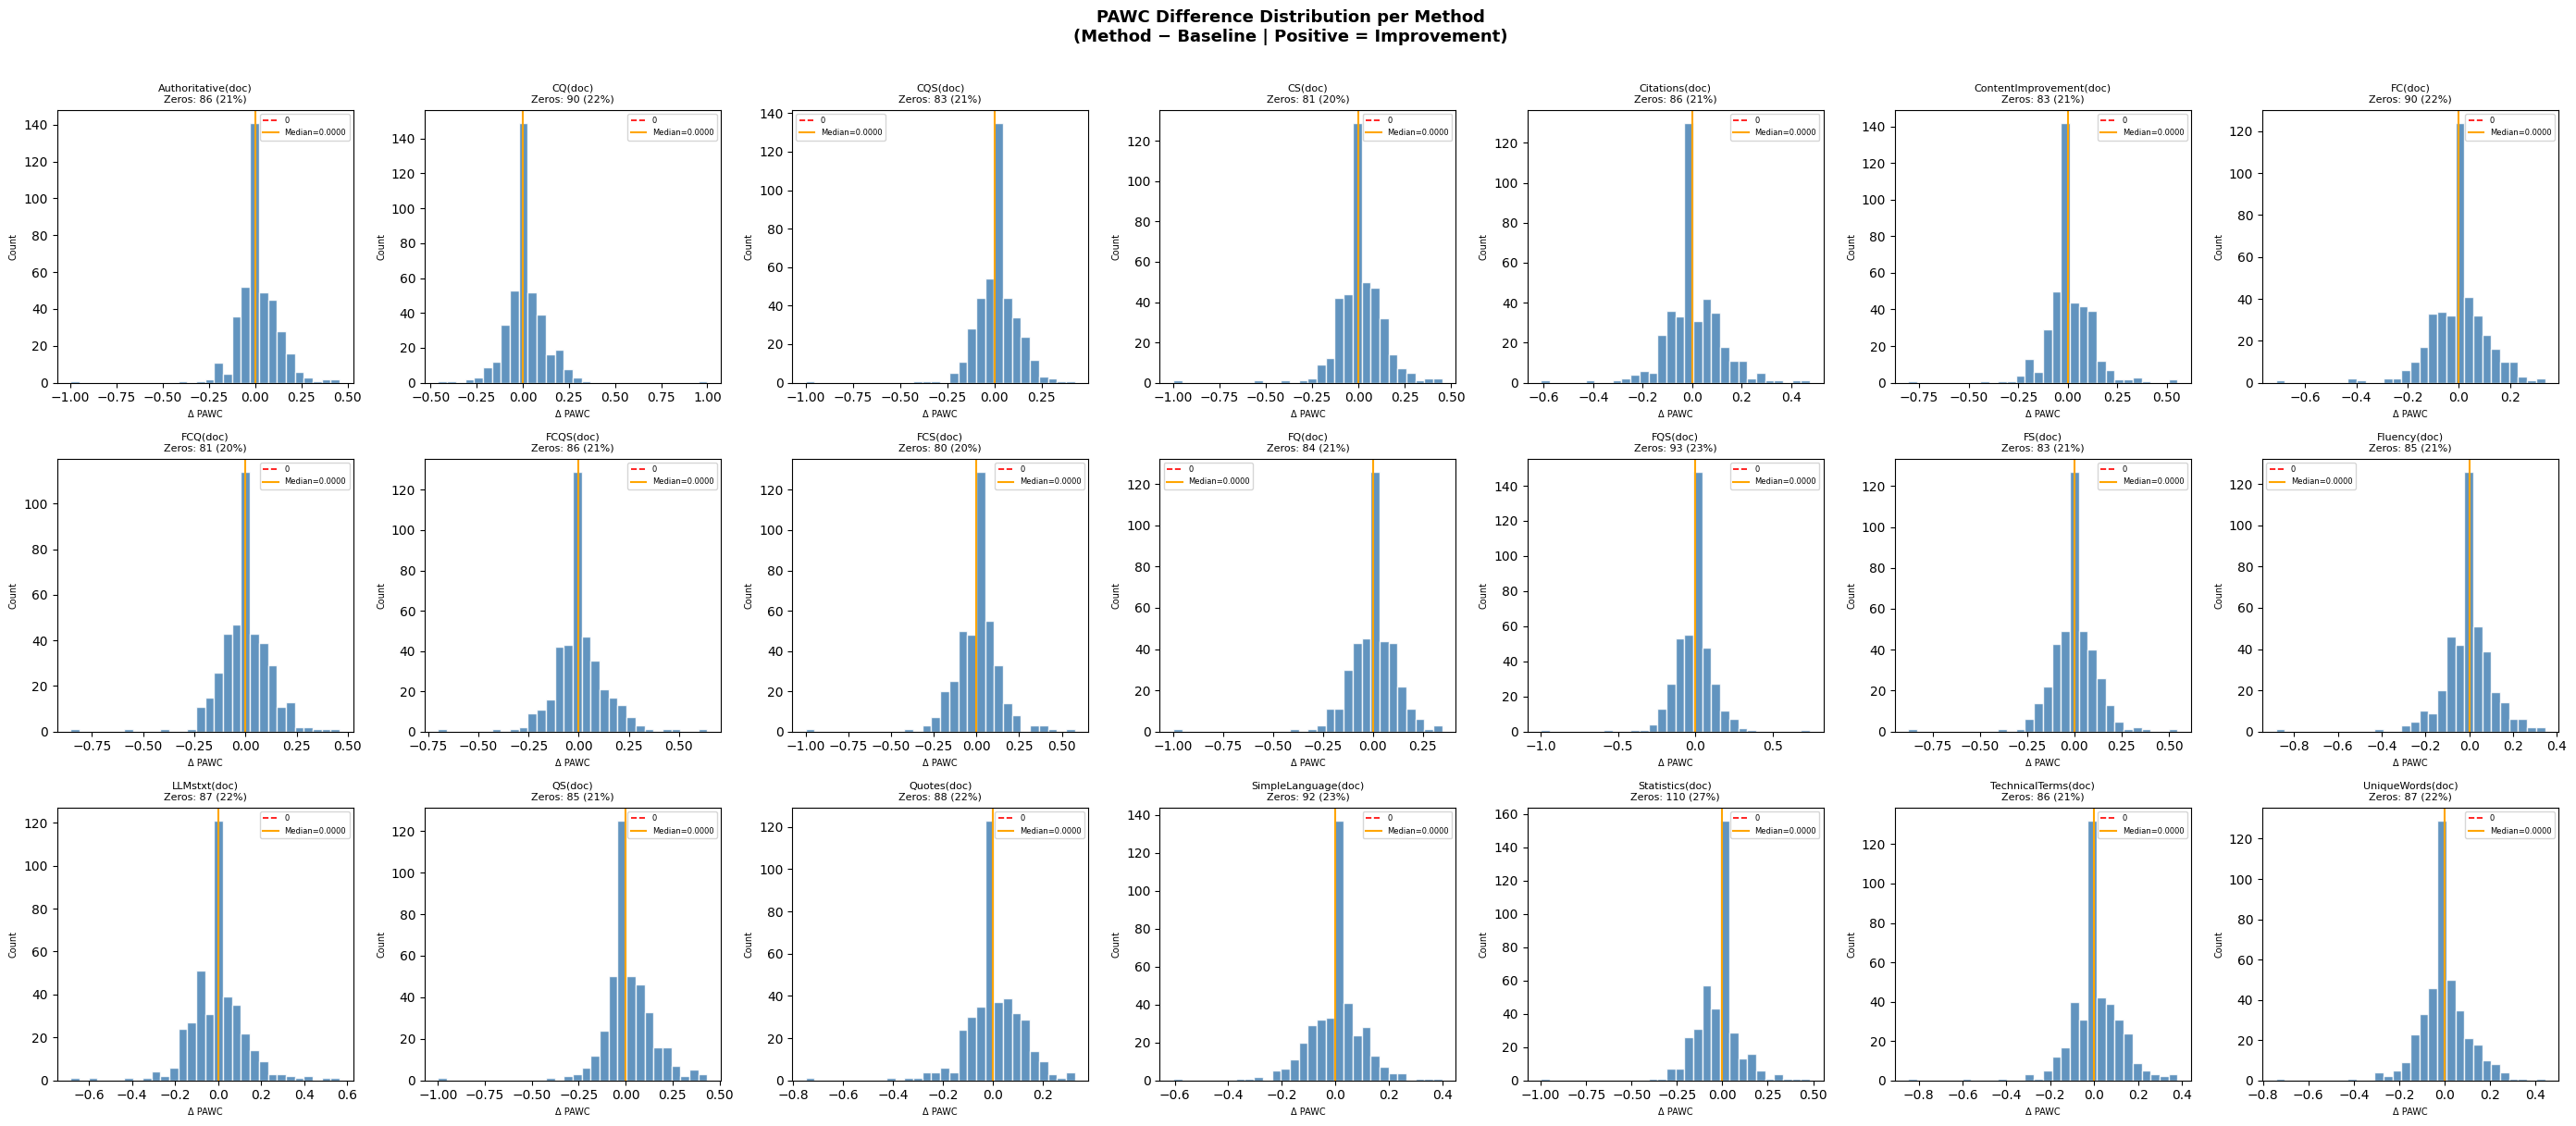

In [50]:
# Diagnostic: Distribution of PAWC Differences
# Checks symmetry assumption for Wilcoxon Signed-Rank Test

from scipy.stats import skew

# Compute PAWC if not already done
if "pawc" not in df.columns:
    print("Computing PAWC for all runs...")
    df["pawc"] = df.apply(compute_pawc_for_row, axis=1)

df_base_pawc = df[df["method"] == "doc"][["original_query_id", "pawc"]].rename(columns={"pawc": "pawc_baseline"})

fig, axes = plt.subplots(3, 7, figsize=(28, 12))
axes = axes.flatten()

print("\nPAWC Symmetry Diagnostics:")
print(f"{'Method':<30} {'N':>5} {'Zeros':>7} {'%Zeros':>8} {'Median':>8} {'Mean':>8} {'Skew':>8}")
print("-" * 80)

for idx, method in enumerate(all_methods):
    df_mp  = df[df["method"] == method][["original_query_id", "pawc"]].rename(columns={"pawc": "pawc_method"})
    merged = df_base_pawc.merge(df_mp, on="original_query_id")
    diffs  = (merged["pawc_method"] - merged["pawc_baseline"]).values

    n_zeros   = (diffs == 0).sum()
    pct_zeros = n_zeros / len(diffs) * 100

    ax = axes[idx]
    ax.hist(diffs, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(0, color="red", linewidth=1.2, linestyle="--", label="0")
    ax.axvline(np.median(diffs), color="orange", linewidth=1.5, linestyle="-", label=f"Median={np.median(diffs):.4f}")
    ax.set_title(f"{method}\nZeros: {n_zeros} ({pct_zeros:.0f}%)", fontsize=8)
    ax.set_xlabel("Δ PAWC", fontsize=7)
    ax.set_ylabel("Count", fontsize=7)
    ax.legend(fontsize=6)

    print(f"  {method:<28} {len(diffs):>5} {n_zeros:>7} {pct_zeros:>7.1f}% {np.median(diffs):>8.4f} {np.mean(diffs):>8.4f} {skew(diffs):>8.3f}")

# Hide unused subplots
for j in range(len(all_methods), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("PAWC Difference Distribution per Method\n(Method − Baseline | Positive = Improvement)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [51]:
# Extract baseline PAWC scores — one value per query
df_base_pawc = df[df["method"] == "doc"][["original_query_id", "pawc"]].rename(columns={"pawc": "pawc_baseline"})

pawc_results = []
for method in all_methods:
    df_mp  = df[df["method"] == method][["original_query_id", "pawc"]].rename(columns={"pawc": "pawc_method"})

    # Merge on query_id to ensure correct pairwise alignment
    merged = df_base_pawc.merge(df_mp, on="original_query_id")
    diffs  = (merged["pawc_method"] - merged["pawc_baseline"]).tolist()
    if len(diffs) < 10:
        continue

    # Wilcoxon Signed-Rank Test with Pratt modification — all three directions
    stat_g, pval_g = wilcoxon(diffs, alternative="greater",   zero_method="pratt")
    stat_l, pval_l = wilcoxon(diffs, alternative="less",      zero_method="pratt")
    stat_t, pval_t = wilcoxon(diffs, alternative="two-sided", zero_method="pratt")

    # Effect size r = Z / sqrt(N)
    N        = len(diffs)
    z_stat   = norm.ppf(1 - pval_g) if 0 < pval_g < 1 else 0.0
    r_effect = abs(z_stat) / np.sqrt(N)

    # Sign Test one-sided (greater) — zeros excluded
    nonzero = np.array(diffs)[np.array(diffs) != 0]
    n_pos   = (nonzero > 0).sum()
    n_total = len(nonzero)
    p_sign  = binomtest(n_pos, n_total, p=0.5, alternative="greater").pvalue if n_total > 0 else None

    pawc_results.append({
        "method":          method,
        "mean_delta_pawc": np.mean(diffs),
        "pvalue_greater":  pval_g,
        "pvalue_less":     pval_l,
        "pvalue_twosided": pval_t,
        "r_effect":        r_effect,
        "p_sign_greater":  p_sign,
        "diffs":           diffs,   # stored for two-sided Sign Test
    })

df_pawc = pd.DataFrame(pawc_results).sort_values("mean_delta_pawc", ascending=False)

# Bonferroni-Holm correction — Wilcoxon and Sign Test separately
_, pg_holm, _, _ = multipletests(df_pawc["pvalue_greater"].values, method="holm")
_, ps_holm, _, _ = multipletests(df_pawc["p_sign_greater"].values, method="holm")
df_pawc["pvalue_greater_holm"] = pg_holm
df_pawc["p_sign_greater_holm"] = ps_holm

# Combined table — Wilcoxon and Sign Test side by side
print("Confirmatory — Wilcoxon One-Sided (greater) + Pratt | Sign Test One-Sided (greater)")
print("Bonferroni-Holm correction applied separately to each test across 21 comparisons")
print()
print(f"{'Method':<30} {'Δ PAWC':>10} {'p Wil(raw)':>12} {'Sig':>4} {'p Wil(Holm)':>13} {'Sig':>4} {'p Sign(raw)':>13} {'Sig':>4} {'p Sign(Holm)':>14} {'Sig':>4} {'r':>8}")
print("-" * 150)
for _, row in df_pawc.iterrows():
    sig_wil_raw   = "*" if row["pvalue_greater"]      < 0.05 else ""
    sig_wil_holm  = "*" if row["pvalue_greater_holm"] < 0.05 else ""
    sig_sign_raw  = "*" if row["p_sign_greater"]      < 0.05 else ""
    sig_sign_holm = "*" if row["p_sign_greater_holm"] < 0.05 else ""
    print(
        f"  {row['method']:<28} {row['mean_delta_pawc']:>10.6f}"
        f" {row['pvalue_greater']:>12.4g} {sig_wil_raw:>4}"
        f" {row['pvalue_greater_holm']:>13.4g} {sig_wil_holm:>4}"
        f" {row['p_sign_greater']:>13.4g} {sig_sign_raw:>4}"
        f" {row['p_sign_greater_holm']:>14.4g} {sig_sign_holm:>4}"
        f" {row['r_effect']:>8.4f}"
    )

print()
print("Positive Δ PAWC = more prominent citation. Negative = less prominent.")
print("Effect size r: 0.1 = small, 0.3 = medium, 0.5 = large.")

Confirmatory — Wilcoxon One-Sided (greater) + Pratt | Sign Test One-Sided (greater)
Bonferroni-Holm correction applied separately to each test across 21 comparisons

Method                             Δ PAWC   p Wil(raw)  Sig   p Wil(Holm)  Sig   p Sign(raw)  Sig   p Sign(Holm)  Sig        r
------------------------------------------------------------------------------------------------------------------------------------------------------
  QS(doc)                        0.019244    0.0006776    *       0.01423    *      0.002451    *        0.05147        0.1598
  Authoritative(doc)             0.013777     0.003822    *       0.07644            0.01861    *         0.3723        0.1330
  CQ(doc)                        0.013445      0.01783    *        0.3032            0.06312                   1        0.1048
  CS(doc)                        0.012088      0.01368    *        0.2599            0.04695    *         0.7981        0.1100
  ContentImprovement(doc)        0.010441      0

In [52]:
# Two-sided test — motivated by unexpected negative effect of Statistics(doc)

# Sign Test two-sided — zeros excluded as uninformative for sign direction
def sign_test_twosided(diffs):
    nonzero = np.array(diffs)[np.array(diffs) != 0]
    if len(nonzero) == 0:
        return None
    n_pos = (nonzero > 0).sum()
    return binomtest(n_pos, len(nonzero), p=0.5, alternative="two-sided").pvalue

df_pawc["p_sign_twosided"] = df_pawc["diffs"].apply(sign_test_twosided)

# Bonferroni-Holm correction — Wilcoxon and Sign Test separately
_, pt_holm, _, _ = multipletests(df_pawc["pvalue_twosided"].values, method="holm")
_, ps_holm, _, _ = multipletests(df_pawc["p_sign_twosided"].values, method="holm")
df_pawc["pvalue_twosided_holm"] = pt_holm
df_pawc["p_sign_twosided_holm"] = ps_holm

# Combined table — consistent results across both tests confirm robustness
print("Post Hoc Exploratory — Wilcoxon Two-Sided + Pratt | Sign Test Two-Sided")
print("Bonferroni-Holm correction applied separately to each test across 21 comparisons")
print()
print(f"{'Method':<30} {'Δ PAWC':>10} {'p Wil(raw)':>12} {'Sig':>4} {'p Wil(Holm)':>13} {'Sig':>4} {'p Sign(raw)':>13} {'Sig':>4} {'p Sign(Holm)':>14} {'Sig':>4} {'r':>8}")
print("-" * 150)
for _, row in df_pawc.iterrows():
    sig_wil_raw   = "*" if row["pvalue_twosided"]      < 0.05 else ""
    sig_wil_holm  = "*" if row["pvalue_twosided_holm"] < 0.05 else ""
    sig_sign_raw  = "*" if row["p_sign_twosided"]      < 0.05 else ""
    sig_sign_holm = "*" if row["p_sign_twosided_holm"] < 0.05 else ""
    print(
        f"  {row['method']:<28} {row['mean_delta_pawc']:>10.6f}"
        f" {row['pvalue_twosided']:>12.4g} {sig_wil_raw:>4}"
        f" {row['pvalue_twosided_holm']:>13.4g} {sig_wil_holm:>4}"
        f" {row['p_sign_twosided']:>13.4g} {sig_sign_raw:>4}"
        f" {row['p_sign_twosided_holm']:>14.4g} {sig_sign_holm:>4}"
        f" {row['r_effect']:>8.4f}"
    )

print()
print("Positive Δ PAWC = more prominent citation. Negative = less prominent.")
print("Effect size r: 0.1 = small, 0.3 = medium, 0.5 = large.")

Post Hoc Exploratory — Wilcoxon Two-Sided + Pratt | Sign Test Two-Sided
Bonferroni-Holm correction applied separately to each test across 21 comparisons

Method                             Δ PAWC   p Wil(raw)  Sig   p Wil(Holm)  Sig   p Sign(raw)  Sig   p Sign(Holm)  Sig        r
------------------------------------------------------------------------------------------------------------------------------------------------------
  QS(doc)                        0.019244     0.001355    *        0.0271    *      0.004902    *        0.09804        0.1598
  Authoritative(doc)             0.013777     0.007644    *        0.1452            0.03723    *         0.7073        0.1330
  CQ(doc)                        0.013445      0.03567    *        0.5707             0.1262                   1        0.1048
  CS(doc)                        0.012088      0.02735    *        0.4924            0.09389                   1        0.1100
  ContentImprovement(doc)        0.010441      0.08265      